<a href="https://colab.research.google.com/github/ka5hely/MSSP-6070-Practical-Programming/blob/main/Assignments/Assignment%201/ASSIGNMENT_1_Asking_questions_about_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Case Study Report Assignment 1
**Analysis on Engineering Students' Academic Records**

- This data analysis looks into data on the results in national assessments for secondary and university education in engineering students. The data contains academic, social, economic information for 12,411 students.

## DATA IMPORT & CLEANING

In [73]:
# Granting access to import file from google drive
from google.colab import drive
drive.mount('/content/drive')

# Connect to my Github repository
from google.colab import userdata
import os

github_token = userdata.get('GitHub')
owner = 'ka5hely'
repository = 'MSSP-6070-Practical-Programming'

clone_url = f'https://{github_token}@github.com/{owner}/{repository}.git'

!git clone {clone_url}

os.chdir(repository)
print(f"Changed directory to: {os.getcwd()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cloning into 'MSSP-6070-Practical-Programming'...
remote: Enumerating objects: 173, done.
remote: Counting objects: 100% (173/173), done.
remote: Compressing objects: 100% (162/162), done.
remote: Total 173 (delta 73), reused 7 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (173/173), 1.32 MiB | 4.85 MiB/s, done.
Resolving deltas: 100% (73/73), done.
Changed directory to: /content/MSSP-6070-Practical-Programming/MSSP-6070-Practical-Programming/MSSP-6070-Practical-Programming


In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

os.chdir("/content/drive/MyDrive/MSSP607/Assignments/Assignment 1")

In [75]:
# Importing the file

df_raw = pd.read_csv(
    "/content/drive/MyDrive/MSSP607/Assignments/Assignment 1/data_academic_performance.csv")

df_raw.head(10)

,COD_S11,GENDER,EDU_FATHER,EDU_MOTHER,OCC_FATHER,OCC_MOTHER,STRATUM,SISBEN,PEOPLE_HOUSE,Unnamed: 9,...,CC_PRO,ENG_PRO,WC_PRO,FEP_PRO,G_SC,PERCENTILE,2ND_DECILE,QUARTILE,SEL,SEL_IHE
0,SB11201210000129,F,Incomplete Professional Education,Complete technique or technology,Technical or professional level employee,Home,Stratum 4,It is not classified by the SISBEN,Three,NaN,...,71,93,79,181,180,91,5,4,2,2
1,SB11201210000137,F,Complete Secundary,Complete professional education,Entrepreneur,Independent professional,Stratum 5,It is not classified by the SISBEN,Three,NaN,...,86,98,78,201,182,92,5,4,4,4
2,SB11201210005154,M,Not sure,Not sure,Independent,Home,Stratum 2,Level 2,Five,NaN,...,18,43,22,113,113,7,1,1,1,1
3,SB11201210007504,F,Not sure,Not sure,Other occupation,Independent,Stratum 2,It is not classified by the SISBEN,Three,NaN,...,76,80,48,137,157,67,4,3,2,2
4,SB11201210007548,M,Complete professional education,Complete professional education,Executive,Home,Stratum 4,It is not classified by the SISBEN,One,NaN,...,98,100,71,189,198,98,5,4,4,2
5,SB11201210007568,F,Complete professional education,Complete professional education,Independent,Executive,Stratum 6,It is not classified by the SISBEN,Three,NaN,...,32,97,36,170,154,63,4,3,4,2
6,SB11201210007598,M,Complete professional education,Complete professional education,Small entrepreneur,Executive,Stratum 5,It is not classified by the SISBEN,Four,NaN,...,50,92,53,187,152,59,3,3,2,2
7,SB11201210007615,F,Incomplete Secundary,Complete Secundary,Entrepreneur,Independent professional,Stratum 6,It is not classified by the SISBEN,Five,NaN,...,94,97,98,188,200,99,5,4,4,4
8,SB11201210010208,M,Complete Secundary,Complete professional education,Independent,Operator,Stratum 2,It is not classified by the SISBEN,Three,NaN,...,43,3,19,177,133,28,2,2,3,2
9,SB11201210013577,M,Incomplete technical or technological,Incomplete technical or technological,Independent,Home,Stratum 2,Level 2,Four,NaN,...,22,83,1,112,126,18,1,1,4,2


In [76]:
# Checked and noticed a variable called 'Unnamed: 9'
# which contains nothing and should be removed
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12411 entries, 0 to 12410
Data columns (total 45 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   COD_S11           12411 non-null  object 
 1   GENDER            12411 non-null  object 
 2   EDU_FATHER        12411 non-null  object 
 3   EDU_MOTHER        12411 non-null  object 
 4   OCC_FATHER        12411 non-null  object 
 5   OCC_MOTHER        12411 non-null  object 
 6   STRATUM           12411 non-null  object 
 7   SISBEN            12411 non-null  object 
 8   PEOPLE_HOUSE      12411 non-null  object 
 9   Unnamed: 9        0 non-null      float64
 10  INTERNET          12411 non-null  object 
 11  TV                12411 non-null  object 
 12  COMPUTER          12411 non-null  object 
 13  WASHING_MCH       12411 non-null  object 
 14  MIC_OVEN          12411 non-null  object 
 15  CAR               12411 non-null  object 
 16  DVD               12411 non-null  object

In [77]:
df = df_raw.drop(columns=['Unnamed: 9'])
df.isnull().any() # There's no clearly missing data after cleaning
# Yet the file does contain answers like 'Not sure', '0', 'Ninguno' (None)
# which deserves our attention in later analysis

,0
COD_S11,False
GENDER,False
EDU_FATHER,False
EDU_MOTHER,False
OCC_FATHER,False
OCC_MOTHER,False
STRATUM,False
SISBEN,False
PEOPLE_HOUSE,False
INTERNET,False


## EXPLORATORY DATA ANALYSIS

In [78]:
df.shape # After cleaning, the dimensionality of the dataframe:
# 12411 observations, and 44 variables

(12411, 44)

In [79]:
df.info() # Check variables names and types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12411 entries, 0 to 12410
Data columns (total 44 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   COD_S11           12411 non-null  object
 1   GENDER            12411 non-null  object
 2   EDU_FATHER        12411 non-null  object
 3   EDU_MOTHER        12411 non-null  object
 4   OCC_FATHER        12411 non-null  object
 5   OCC_MOTHER        12411 non-null  object
 6   STRATUM           12411 non-null  object
 7   SISBEN            12411 non-null  object
 8   PEOPLE_HOUSE      12411 non-null  object
 9   INTERNET          12411 non-null  object
 10  TV                12411 non-null  object
 11  COMPUTER          12411 non-null  object
 12  WASHING_MCH       12411 non-null  object
 13  MIC_OVEN          12411 non-null  object
 14  CAR               12411 non-null  object
 15  DVD               12411 non-null  object
 16  FRESH             12411 non-null  object
 17  PHONE       

In [80]:
# A quick check on a few variables for myself
print(df['EDU_MOTHER'].value_counts())
print(df['EDU_FATHER'].value_counts()) # TO DO: turn stuff into different levels
print(df['GENDER'].value_counts())
print(df['STRATUM'].value_counts())

EDU_MOTHER
Complete Secundary                       3106
Complete professional education          3059
Complete technique or technology         1495
Incomplete Secundary                     1056
Postgraduate education                    997
Complete primary                          713
Incomplete primary                        541
Incomplete Professional Education         502
0                                         388
Incomplete technical or technological     341
Not sure                                  179
Ninguno                                    34
Name: count, dtype: int64
EDU_FATHER
Complete professional education          3016
Complete Secundary                       2843
Complete technique or technology         1194
Incomplete Secundary                     1091
Postgraduate education                   1085
Complete primary                          824
Incomplete primary                        735
Incomplete Professional Education         425
Not sure                        

In [81]:
# A quick overview of scores distribution

df[['MAT_S11', 'CR_S11', 'CC_S11', 'BIO_S11', 'ENG_S11',
    'QR_PRO', 'CR_PRO', 'CC_PRO', 'ENG_PRO', 'WC_PRO',
    'FEP_PRO', 'G_SC']].describe().round(2)

,MAT_S11,CR_S11,CC_S11,BIO_S11,ENG_S11,QR_PRO,CR_PRO,CC_PRO,ENG_PRO,WC_PRO,FEP_PRO,G_SC
count,12411.00,12411.00,12411.00,12411.00,12411.0,12411.00,12411.00,12411.00,12411.0,12411.0,12411.00,12411.00
mean,64.32,60.78,60.71,63.95,61.8,77.42,62.20,59.19,67.5,53.7,145.48,162.71
std,11.87,10.03,10.12,11.16,14.3,22.67,27.67,28.99,25.5,30.0,40.13,23.11
min,26.00,24.00,0.00,11.00,26.0,1.00,1.00,1.00,1.0,0.0,1.00,37.00
25%,56.00,54.00,54.00,56.00,50.0,65.00,42.00,36.00,51.0,28.0,124.00,147.00
50%,64.00,61.00,60.00,64.00,59.0,85.00,67.00,65.00,74.0,56.0,153.00,163.00
75%,72.00,67.00,67.00,71.00,72.0,96.00,86.00,85.00,88.0,80.0,174.00,179.00
max,100.00,100.00,100.00,100.00,100.0,100.00,100.00,100.00,100.0,100.0,300.00,247.00


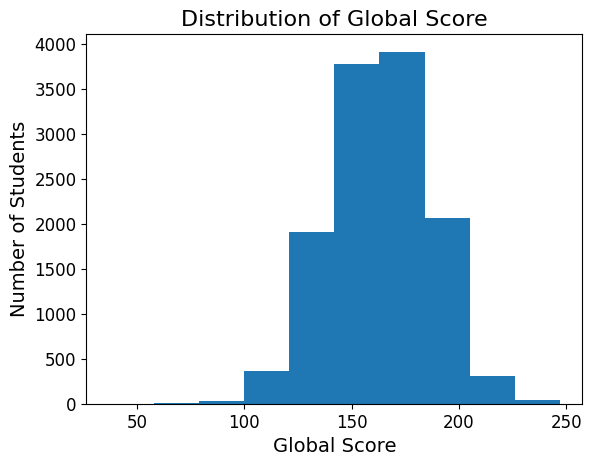

In [82]:
# Visualize Global Score

plt.hist(df['G_SC'])
plt.title("Distribution of Global Score")
plt.xlabel("Global Score")
plt.ylabel("Number of Students")
plt.show() # Basically a normal distribution

## Question 1: Parents' Education

In [83]:
# First I want to check the distribution of parents' education and the global score related
# One problem is the education is listed in alphabetical order
# Yet it would be clearer if it can follow a normal ascending order
df = df.copy().dropna()
df.loc[:, "EDU_FATHER"] = df["EDU_FATHER"].str.strip() # After some failures I realized some answers include space
df.loc[:, "EDU_MOTHER"] = df["EDU_MOTHER"].str.strip()

education_code = {
    '0': np.nan,
    'Not sure': np.nan,
    "Ninguno": 0,
    "Incomplete primary": 1,
    "Complete primary": 2,
    "Incomplete Secundary": 3,
    "Complete Secundary": 4,
    "Incomplete technical or technological": 5,
    "Complete technique or technology": 6,
    "Incomplete Professional Education": 7,
    "Complete professional education": 8,
    "Postgraduate education": 9
}

df.loc[:, "EDU_FATHER_CODE"] = df['EDU_FATHER'].map(education_code)
df.loc[:, "EDU_MOTHER_CODE"] = df['EDU_MOTHER'].map(education_code)

# I think adding percentage makes the info clearer
percentage = lambda x: round(x.value_counts(normalize=True) * 100, 2)

father_summary = (
    df.groupby('EDU_FATHER_CODE')['G_SC']
    .agg(['count', 'mean', 'std'])
    .round(2))

mother_summary = (
    df.groupby('EDU_MOTHER_CODE')['G_SC']
    .agg(['count', 'mean', 'std'])
    .round(2))

father_summary['%'] = percentage(df['EDU_FATHER_CODE'])
mother_summary['%'] = percentage(df['EDU_MOTHER_CODE'])

parent_summary = pd.concat(
    [father_summary, mother_summary],
    axis=1,
    keys=["Father", "Mother"])

parent_summary

Father                       Mother                      
     count    mean    std      %  count    mean    std      %
0.0    123  156.63  23.19   1.06     34  149.71  27.93   0.29
1.0    735  155.73  20.94   6.33    541  154.85  21.64   4.57
2.0    824  155.20  22.41   7.10    713  155.34  22.01   6.02
3.0   1091  156.54  21.74   9.39   1056  155.67  21.93   8.92
4.0   2843  158.79  22.11  24.48   3106  158.47  21.95  26.22
5.0    277  162.10  21.88   2.39    341  161.88  20.74   2.88
6.0   1194  164.03  22.17  10.28   1495  163.24  21.94  12.62
7.0    425  166.92  22.69   3.66    502  166.69  22.93   4.24
8.0   3016  167.77  23.03  25.97   3059  168.85  22.98  25.83
9.0   1085  176.99  21.73   9.34    997  175.64  22.12   8.42

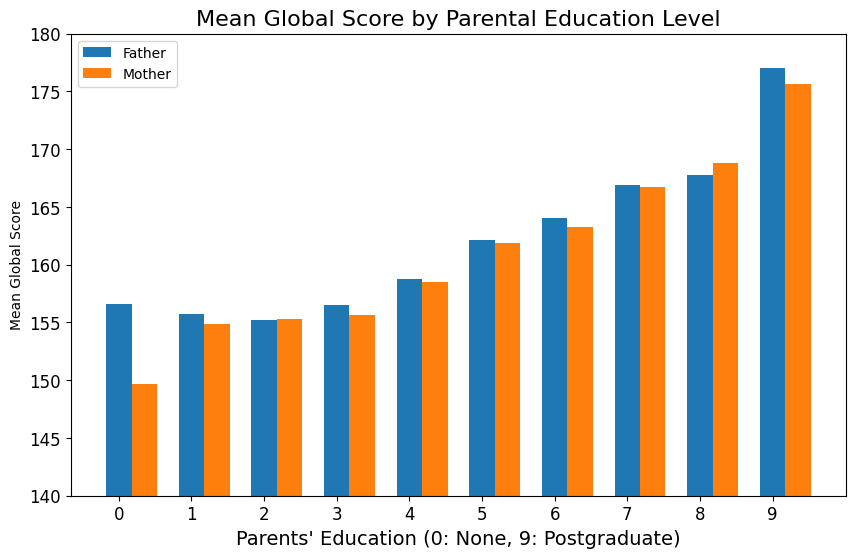

In [84]:
# Visualization can help see clearer

# This was taken from Assignment_2_Example on canvas
plt.rcParams.update({
    'font.size': 9,          # Base font size
    'axes.titlesize': 16,     # Title font size
    'axes.labelsize': 14,     # Axis label font size
    'xtick.labelsize': 12,    # X tick labels
    'ytick.labelsize': 12,    # Y tick labels
    'legend.fontsize': 12,    # Legend
})
education_label = list(education_code.keys())
positions = np.arange(len(education_label) - 2)
bar_width = 0.35

# Plotting parental education side by side
plt.figure(figsize=(10, 6))

father_bars = plt.bar(
    positions,
    father_summary["mean"],
    bar_width,
    label="Father")

mother_bars = plt.bar(
    positions + bar_width,
    mother_summary["mean"],
    bar_width,
    label="Mother")

plt.title("Mean Global Score by Parental Education Level")
plt.xlabel("Parents' Education (0: None, 9: Postgraduate)", fontsize=14)
plt.ylabel("Mean Global Score", fontsize=10)
plt.legend(fontsize=10)
plt.xticks(range(10))
plt.ylim(140, 180)
plt.tight_layout
plt.show()

In [85]:
# Since father's and mother's education show similar patterns and are highly correlated with each other,
# I want to extract the highest education level in the household to summarize overall parental education's influence on G_SC.

df["EDU_HIGHEST_CODE"] = df[["EDU_FATHER_CODE", "EDU_MOTHER_CODE"]].max(axis=1)

highest_summary = (
    df.groupby('EDU_HIGHEST_CODE')['G_SC']
    .agg(['count', 'mean', 'std'])
    .round(2)
)
highest_summary['%'] = percentage(df['EDU_HIGHEST_CODE'])
highest_summary

,count,mean,std,%
EDU_HIGHEST_CODE,,,,
0.0,20,146.70,29.57,0.17
1.0,372,154.23,21.40,3.11
2.0,526,154.79,22.08,4.40
3.0,788,155.20,21.29,6.59
4.0,2702,157.21,22.08,22.58
5.0,301,160.66,20.90,2.52
6.0,1387,161.22,21.84,11.59
7.0,452,164.08,22.63,3.78
8.0,3832,166.33,22.86,32.02


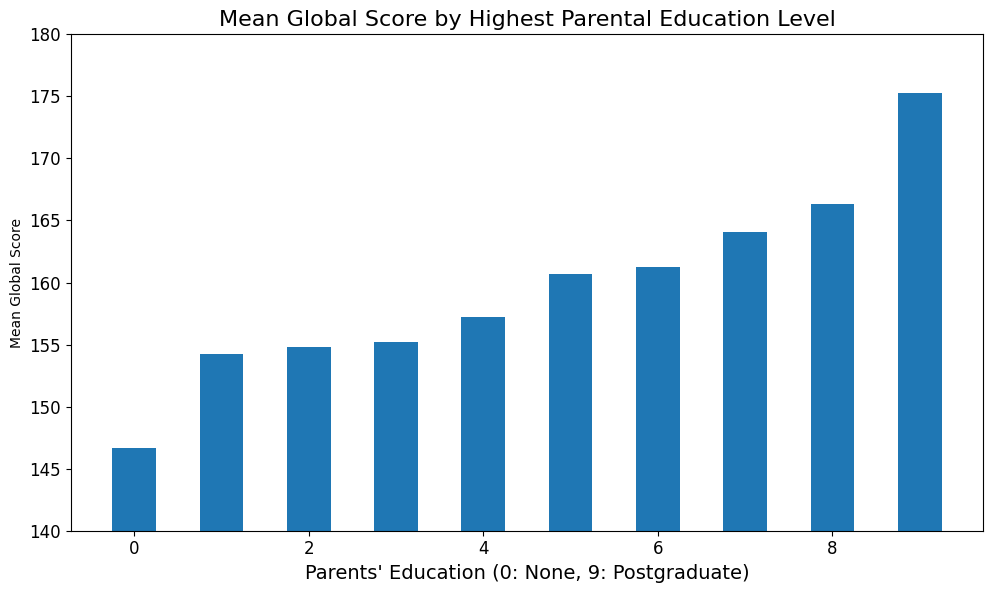

In [97]:
# Visualization

plt.figure(figsize=(10, 6))

highest_bars = plt.bar(
    highest_summary.index,
    highest_summary["mean"],
    width=0.5,
    label="Parent")

plt.title("Mean Global Score by Highest Parental Education Level")
plt.xlabel("Parents' Education (0: None, 9: Postgraduate)", fontsize=14)
plt.ylabel("Mean Global Score", fontsize=10)
plt.ylim(140, 180)
plt.tight_layout()

#plt.savefig(
#    "parental_education_and_global_score.png",
#   dpi=300,
#    bbox_inches="tight"
#)

plt.show()

In [87]:
# Because the parental education level has a sort of ranking, it is more appriopraite to use Spearman rank correlation
# The python way of conducting correlation is learned from scipy documentation
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html

from scipy import stats

edu_corr = stats.spearmanr(
    df["EDU_HIGHEST_CODE"],
    df["G_SC"]
)

print("Spearman correlation:", round(edu_corr.statistic, 3))
print("p-value:", edu_corr.pvalue)

Spearman correlation: nan
p-value: nan


## Question 2: Groups Performances

In [88]:
# Check the distribution of stratum
# Some of the answers are 0, and should be eliminated from analysis
print(df["STRATUM"].unique()) # the 0s here are strings

df = df[df['STRATUM'] != "0"]
stratum_des = pd.DataFrame(df['STRATUM'].value_counts())
stratum_des['%'] = percentage(df['STRATUM'])
stratum_des


['Stratum 4' 'Stratum 5' 'Stratum 2' 'Stratum 6' 'Stratum 3' 'Stratum 1'
 '0']


,count,%
STRATUM,,
Stratum 3,4045,32.63
Stratum 2,4029,32.50
Stratum 1,1709,13.79
Stratum 4,1578,12.73
Stratum 5,633,5.11
Stratum 6,403,3.25


In [89]:
stratum_code = {
    "Stratum 1": 1,
    "Stratum 2": 2,
    "Stratum 3": 3,
    "Stratum 4": 4,
    "Stratum 5": 5,
    "Stratum 6": 6,
}

df['STRATUM_CODE'] = df['STRATUM'].replace(stratum_code)

stratum_summary = (
    df.groupby('STRATUM_CODE')['G_SC']
    .agg(['count', 'mean'])
    .round(2))

stratum_summary['%'] = percentage(df['STRATUM_CODE'])

stratum_summary

/tmp/ipykernel_3091/296780806.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['STRATUM_CODE'] = df['STRATUM'].replace(stratum_code)


,count,mean,%
STRATUM_CODE,,,
1,1709,152.35,13.79
2,4029,158.20,32.50
3,4045,163.82,32.63
4,1578,172.00,12.73
5,633,177.39,5.11
6,403,181.51,3.25


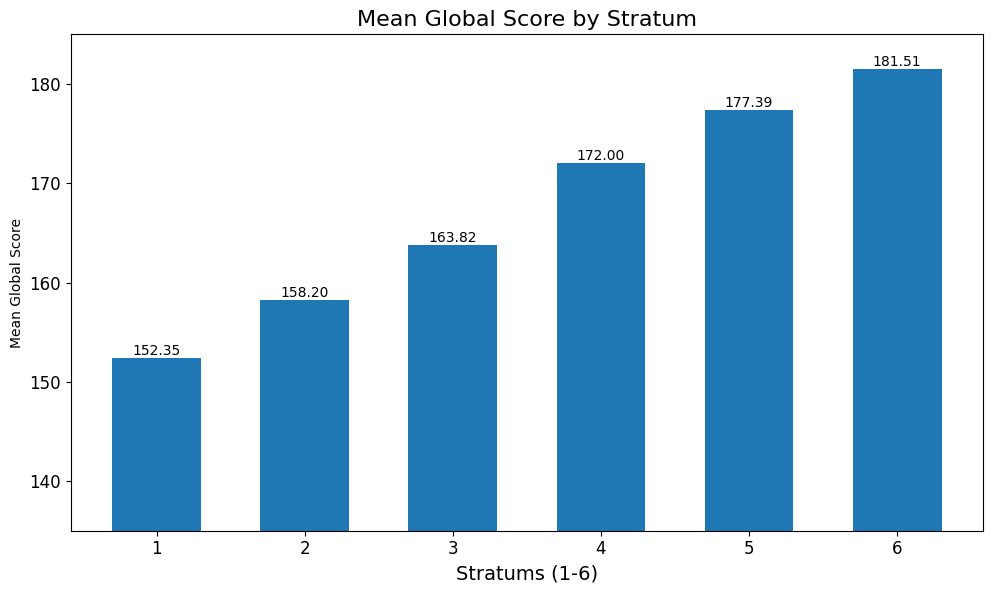

In [98]:
plt.figure(figsize=(10, 6))

bar_width = 0.6

stratum_bars = plt.bar(
    stratum_summary.index,
    stratum_summary["mean"],
    bar_width,
    label="Stratum")

for bar in stratum_bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Mean Global Score by Stratum")
plt.xlabel("Stratums (1-6)", fontsize=14)
plt.ylabel("Mean Global Score", fontsize=10)
plt.ylim(135, 185)
plt.tight_layout()

plt.savefig(
    "stratum_mean_score.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [91]:
stra_corr = stats.spearmanr(
    df["STRATUM_CODE"],
    df["G_SC"]
)

print("Spearman correlation:", round(stra_corr.statistic, 3))
print("p-value:", stra_corr.pvalue)

Spearman correlation: 0.312
p-value: 3.2207958533665364e-277


In [92]:
# Exploring some detailed issues behind strata

df["COMPUTER"] = df["COMPUTER"].str.strip().str.title()
df["INTERNET"] = df["INTERNET"].str.strip().str.title()

yes_no_code = {
    "Yes": 1,
    "No": 0
}

df["COMPUTER_CODE"] = df["COMPUTER"].map(yes_no_code)
df["INTERNET_CODE"] = df["INTERNET"].map(yes_no_code)

resource_summary = (
    df.groupby('STRATUM_CODE')
    .agg(
        Computer_percent = ("COMPUTER_CODE", "mean"),
        Internet_percent = ("INTERNET_CODE", "mean"),
    )
)

resource_summary

,Computer_percent,Internet_percent
STRATUM_CODE,,
1,0.562902,0.423640
2,0.767932,0.721023
3,0.895674,0.886279
4,0.942332,0.960710
5,0.962085,0.982622
6,0.985112,0.987593


## Question 3: Gender

In [93]:
gender_summary = (
    df.groupby('GENDER')['G_SC']
    .agg(['count', 'mean'])
    .round(2))

gender_summary['%'] = percentage(df['GENDER'])

gender_summary

,count,mean,%
GENDER,,,
F,5037,161.29,40.63
M,7360,163.70,59.37


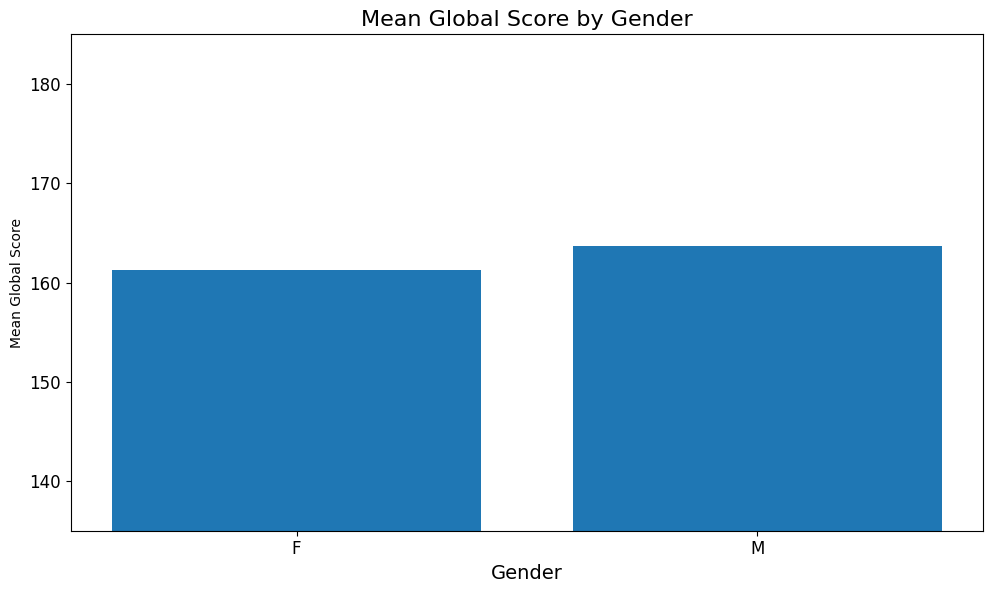

In [94]:
# Visualization

plt.figure(figsize=(10, 6))

plt.bar(
    gender_summary.index,
    gender_summary['mean'])

plt.title("Mean Global Score by Gender")
plt.xlabel("Gender", fontsize=14)
plt.ylabel("Mean Global Score", fontsize=10)
plt.ylim(135, 185)
plt.tight_layout()
plt.show()